# Utilization

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import sys
sys.path.insert(0, "../src/")
from FwdNeuron import *
from DeepEligNeuron import *
from Network import *
from inputFuc import *
from utils import *
from plotting import *

# Compare learning

## Teacher-student in Multi-layer

tensor([ 4, 12])
reach steady state with error: 0.035292


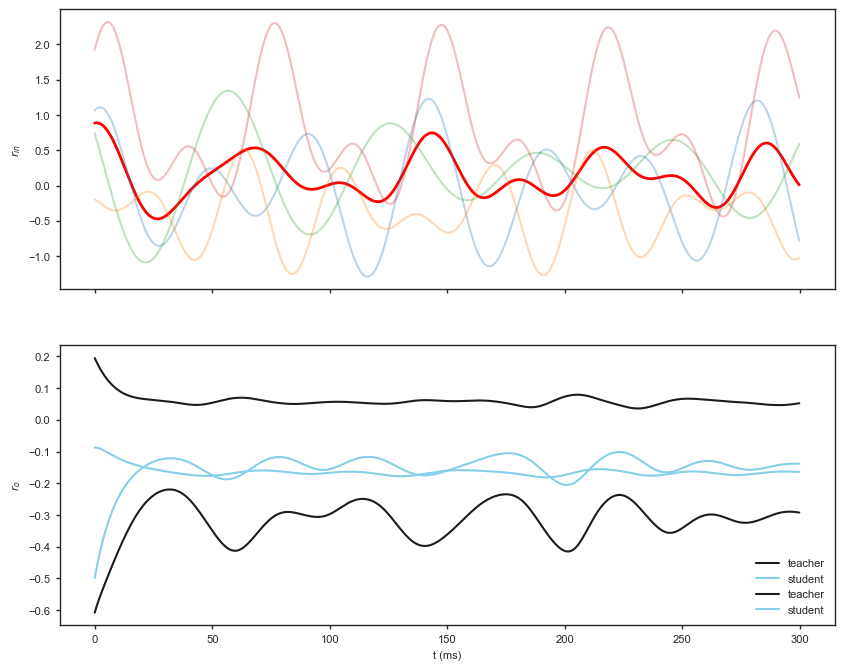

In [18]:
#### With P learning ###
dt = 0.25 #ms

init_phase = 300 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 50000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 200 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
n_in, n_hidden1, n_hidden2, n_out = 4, 3, 2, 2
beta=0.1
activation='sigmoid'

student = DEFwdNetwork(
    layers=[
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau=[1.7, 3., 7.], lr_w=2.0,
                     activation=activation, dt=dt, scale=0.6),
        LastFwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau=[4, 12], lr_w=0.3,
                     activation=activation, dt=dt, scale=1.6),
        FwdNeurons(n_in=n_hidden2, n_neurons=n_out, tau=dt, 
                   lr_w=0.0, activation='linear', dt=dt)
    ],
    beta=beta
)

# n_in, n_hidden1, n_out = 3, 2, 1
# student = FwdNetwork(
#     layers=[
#         FwdEPNeurons(n_in=n_in, n_neurons=n_hidden1, tau=[13, 67], lr_w=1.5,
#                      activation=activation, dt=dt, scale=1.6),
#         FwdNeurons(n_in=n_hidden1, n_neurons=n_out, tau=dt, 
#                    lr_w=0.0, activation='linear', dt=dt, beta=beta)
#     ],)


student2 = FwdNetwork(net=student, layers=FwdRFNeurons)

student3 = FwdNetwork(net=student, layers=FwdGLENeurons)
student_naive = copy.deepcopy(student2)
teacher = copy.deepcopy(student2)
student.reset()

Students={'DeepElig':student, 'Eprop':student2, 'GLE':student3, 'naive':student_naive}



# deviate teacher by small perturbation
with torch.no_grad():
    for i, l in enumerate(student.layers[:-1]):
        deviate = torch.randn(l.W_in.shape)*6e-1
        teacher.layers[i].W_in += deviate
# deviate = torch.randn(teacher.layers[-1].W_in.shape)*1e-2
# teacher.layers[-1].W_in += deviate

input_fuc = mul_sin_function(n=n_in, n_sin=2, period=(20, 80), bias = (-0.5, 0.5), magnitude=(0.2, 1), phase = (0, 6), dt=dt)
#input_fuc = mul_sin_function(n=n_in, n_sin=2, period=(15, 40), bias=(-0.1, 0.1), magnitude=(0.2, 1.0), phase=(0, 6), dt=dt)
#input_fuc = low_pass_OU(size=n_in, lp_tau=(0.5, 2), tau=(10, 25), mu=(-0.2, 0.2), sigma=(0.1, 0.5), dt = dt)


#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

with torch.no_grad():
    
    for t in range(init_phase_steps):
        inp = input_fuc(t)[None,:]
        r_out_target, u_out_target = teacher.step(inp)
        r_out, u_out = student.step(inp)
        r_out1, u_out = student3.step(inp)
        error = u_out_target - u_out
        student.prop(error)
        student2.prop(error)
        Rcd.rec([inp, u_out_target, u_out])
        
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0), color='r', linewidth=2)
for i in range(n_in):
    axs[0].plot(x, Rcd['input'][i][0:], alpha = 0.3)
for i in range(n_out):
    axs[1].plot(x, Rcd['teacher'][i][0:], label="teacher", color = black)
    axs[1].plot(x, Rcd['student'][i][0:], label="student", color = lightblue)
axs[1].legend()
axs[1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [19]:
student.beta *= 16

In [20]:
Cum_errors = 3*[(error**2).mean().item()]
error_record, mismatch_record = [], []
cum_eps = 0
Students['Eprop'].align(student)
Students['GLE'].align(student)
Rcd = Recorder(['dt_tau_de', 'rhod'])

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        inp = input_fuc(t)[None,:]
        r_out_target, u_out_target = teacher.step(inp)
        
        for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            r_out, u_out = Students[stu].step(inp)
            error = u_out_target - u_out
            Students[stu].prop(error)
            Students[stu].learnW()
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()
        
        if (t*dt)%100==0:
            error_record.append(list(Cum_errors))
            
            print("target: ", u_out_target.mean().numpy(), "output: ", u_out.mean().numpy(), 
                  " error: %5e, t: %d ms"%(Cum_errors[0], t*dt))
#Rcd.finish()


target:  -0.120113045 output:  -0.17173025  error: 3.528750e-02, t: 300 ms
target:  -0.14745596 output:  -0.21594585  error: 2.537256e-02, t: 400 ms
target:  -0.08119024 output:  -0.17234465  error: 1.725481e-02, t: 500 ms
target:  -0.14593521 output:  -0.2089523  error: 1.172259e-02, t: 600 ms
target:  -0.14884838 output:  -0.2015321  error: 7.970091e-03, t: 700 ms
target:  -0.12577496 output:  -0.17159711  error: 5.409648e-03, t: 800 ms
target:  -0.12335163 output:  -0.16952616  error: 3.673675e-03, t: 900 ms
target:  -0.18825977 output:  -0.21878943  error: 2.508019e-03, t: 1000 ms
target:  -0.09522919 output:  -0.14930698  error: 1.741294e-03, t: 1100 ms
target:  -0.12499116 output:  -0.17458034  error: 1.185230e-03, t: 1200 ms
target:  -0.11770213 output:  -0.16681884  error: 8.260985e-04, t: 1300 ms
target:  -0.12230338 output:  -0.16349962  error: 5.711674e-04, t: 1400 ms
target:  -0.09495187 output:  -0.14720747  error: 4.195596e-04, t: 1500 ms
target:  -0.11882193 output:  -0.

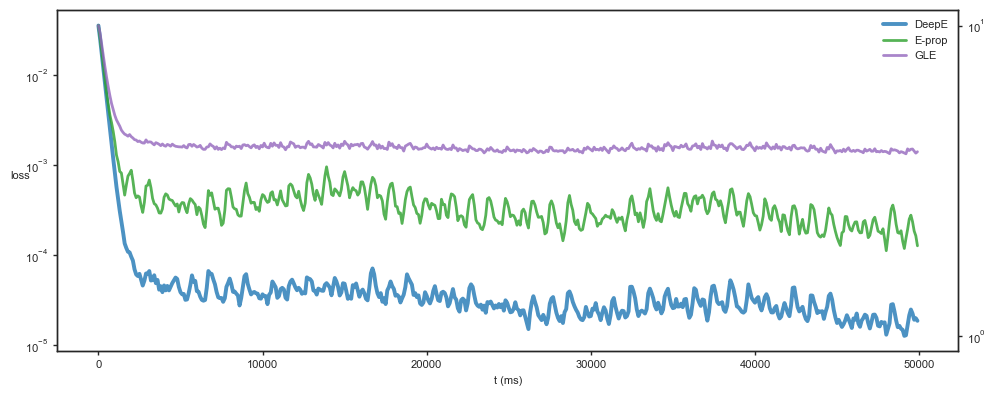

In [21]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*100
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="DeepE", color=blue, linewidth=2.8, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="E-prop", color=green, linewidth=2., alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2., alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

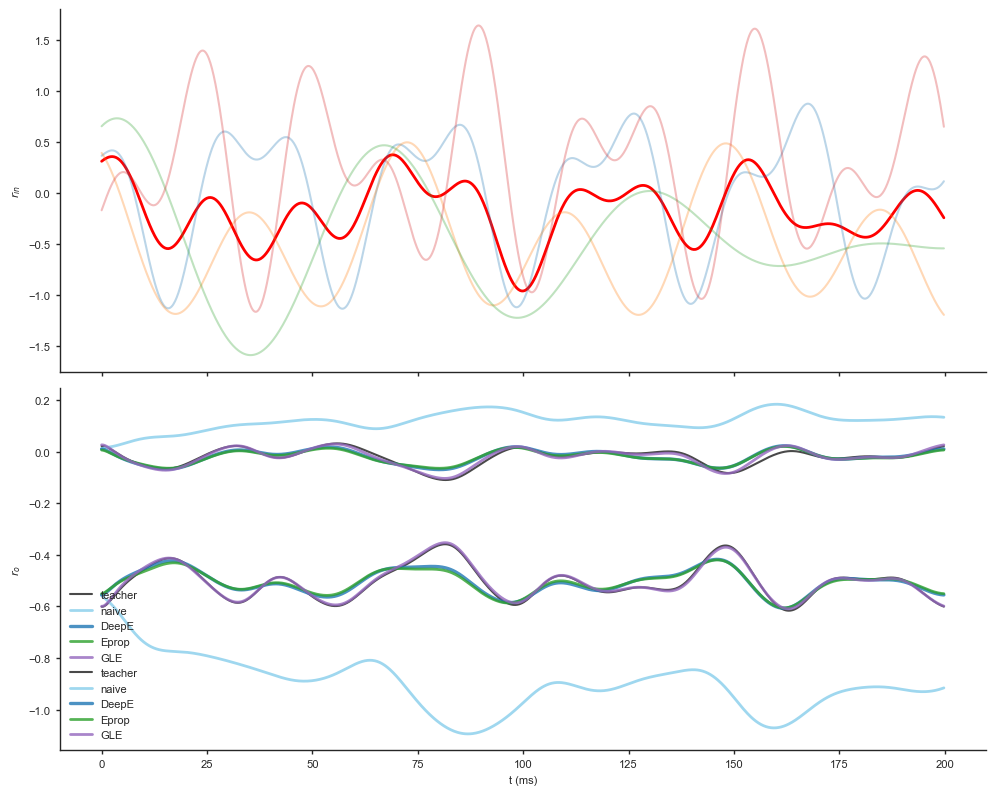

In [10]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'Eprop', 'GLE', 'naive'])
Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        inp = input_fuc(t)[None,:]
        Rcd_eval.rec_single('input', inp)
        r_out_target, u_out_target = teacher.step(inp)
        Rcd_eval.rec_single('teacher', u_out_target)
        for k, stu in Students.items():
            r_out, u_out = stu.step(inp)
            Rcd_eval.rec_single(k, u_out)

Rcd_eval.finish()

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color='r', linewidth=2)
for i in range(n_in):
    axs[0].plot(x, Rcd_eval['input'][i][0:], alpha = 0.3)
for i in range(n_out):
    axs[1].plot(x, Rcd_eval['teacher'][i][0:], label="teacher", color = black, linewidth=1.5, alpha=0.8)
    axs[1].plot(x, Rcd_eval['naive'][i][0:], label="naive", color = lightblue, linewidth=2, alpha=0.8)
    axs[1].plot(x, Rcd_eval['DeepElig'][i][:], label="DeepE", color = blue, linewidth=2.4, alpha=0.8)
    axs[1].plot(x, Rcd_eval['Eprop'][i][:], label="Eprop", color = green, linewidth=2, alpha=0.8)
    axs[1].plot(x, Rcd_eval['GLE'][i][:], label="GLE", color = purple, linewidth=2, alpha=0.8)
axs[1].legend()
axs[1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_o$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAft2L.png')
plt.show()

## N-Sum

reach steady state with error: 0.430498


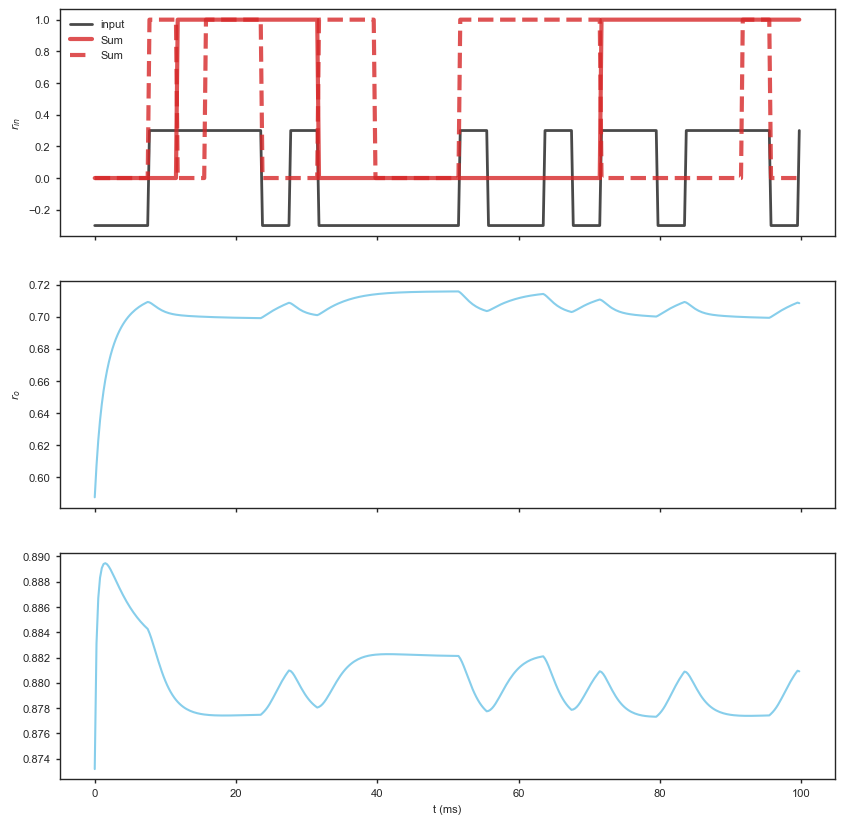

In [2]:
#### With P learning ###
dt = 0.25 #ms

init_phase = 100 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 80000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 100 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
N, bit_time = 3, 4

n_in, n_hidden1, n_hidden2, n_hidden3, n_out = 1, 8, 6, 6, 2
beta=torch.tensor([0.1, 0.5])
activation='sigmoid'

student = DEFwdNetwork(
    layers=torch.nn.ModuleList([
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau = dt*np.logspace(0, 1.4, n_hidden1, dtype=np.float32), lr_w=1e1,
                     activation=activation, dt=dt, scale=1.6),
        FwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau = dt*np.logspace(0, 1.1, n_hidden2, dtype=np.float32), lr_w=2.5,
                     activation=activation, dt=dt, scale=0.4),
        LastFwdDENeurons(n_in=n_hidden2, n_neurons=n_hidden3, tau = [3*dt, 0.4, 3.7, 4.1, 1., 2.], lr_w=0.5,
                     activation='sigmoid', dt=dt, scale=1.6),
        FwdNeurons(n_in=n_hidden3, n_neurons=n_out, tau = dt, 
                   lr_w=0.1, activation='sigmoid', dt=dt, scale=1.)
    ]),
    beta=beta
)


student2 = FwdNetwork(net=student, layers=FwdRFNeurons)

student3 = FwdNetwork(net=student, layers=FwdGLENeurons)
student_naive = copy.deepcopy(student2)

Students={'DeepElig':student, 'Eprop':student2, 'GLE':student3, 'naive':student_naive}

input_fuc = StepSumBi(N=N, bit_time=bit_time, dt=dt)

#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

student.reset()
student2.reset()

with torch.no_grad():
    
    for t in range(init_phase_steps):
        inp, label = input_fuc()
        inp = inp[None,:]
        r_out, u_out = student.step(inp)
        Rcd.rec([inp, label, r_out])
        
    error = label - r_out
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(n_out+1, 1, figsize=(10, 10), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0)*0.6, color=black, label='input', linewidth=2, alpha=0.8)
axs[0].plot(x, Rcd['teacher'][0], label="Sum", color = red, alpha=0.8, linewidth=3)
axs[0].plot(x, Rcd['teacher'][1], label="Sum", color = red, alpha=0.8, linewidth=3, linestyle='--')
for i in range(n_out):
    axs[i+1].plot(x, Rcd['student'][i], label="student %d"%i, color = lightblue)


axs[-1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[0].legend()
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [3]:
Cum_errors = np.array(3*[(error**2).mean().item()])
error_record, mismatch_record = [], []
cum_eps = 0
Students['Eprop'].align(student)
Students['GLE'].align(student)
Rcd = Recorder(['input','rhod'])
decay = torch.tensor([0.997, 0.997])

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        inp, label = input_fuc()
        inp = inp[None,:]
        
        for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            r_out, u_out = Students[stu].step(inp)
            error = label - r_out
            Students[stu].prop(error)
            Students[stu].learnW()
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()

        # Rcd.rec([input, student.mismatch(0), student.mismatch(-1), student.epsilon(1), 
        #          student.layers[0].rho.d, student3.mismatch(0)])

        if (t*dt)%200==0:
            error_record.append(list(Cum_errors))
            beta *= decay
            for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
                Students[stu].layers[-1].beta = beta
            
            print(" error: %5e, t: %d ms"%(Cum_errors[0], t*dt))

Rcd.finish()

 error: 3.781627e-01, t: 200 ms
 error: 3.092469e-01, t: 400 ms
 error: 2.770872e-01, t: 600 ms
 error: 2.612256e-01, t: 800 ms
 error: 2.441517e-01, t: 1000 ms
 error: 2.453539e-01, t: 1200 ms
 error: 2.439495e-01, t: 1400 ms
 error: 2.329670e-01, t: 1600 ms
 error: 2.308487e-01, t: 1800 ms
 error: 2.288467e-01, t: 2000 ms
 error: 2.246398e-01, t: 2200 ms
 error: 2.292382e-01, t: 2400 ms
 error: 2.286698e-01, t: 2600 ms
 error: 2.273241e-01, t: 2800 ms
 error: 2.214548e-01, t: 3000 ms
 error: 2.187622e-01, t: 3200 ms
 error: 2.167394e-01, t: 3400 ms
 error: 2.174565e-01, t: 3600 ms
 error: 2.148016e-01, t: 3800 ms
 error: 2.077772e-01, t: 4000 ms
 error: 2.068340e-01, t: 4200 ms
 error: 2.020195e-01, t: 4400 ms
 error: 2.019280e-01, t: 4600 ms
 error: 2.019232e-01, t: 4800 ms
 error: 2.100808e-01, t: 5000 ms
 error: 2.013798e-01, t: 5200 ms
 error: 2.006762e-01, t: 5400 ms
 error: 2.023267e-01, t: 5600 ms
 error: 1.935803e-01, t: 5800 ms
 error: 2.017792e-01, t: 6000 ms
 error: 1.9885

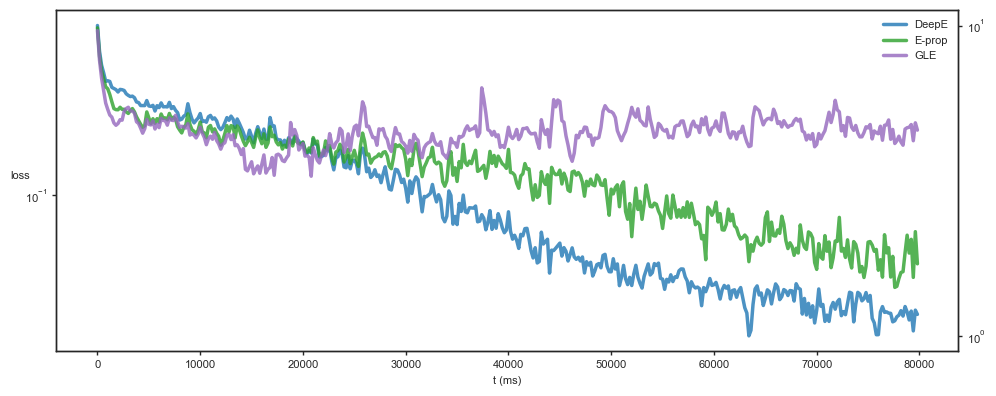

In [4]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*200
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="DeepE", color=blue, linewidth=2.5, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="E-prop", color=green, linewidth=2.5, alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2.5, alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

In [ ]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'Eprop', 'GLE', 'naive'])

#Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        inp, label = input_fuc()
        inp = inp[None,:]
        Rcd_eval.rec_single('input', inp)
        Rcd_eval.rec_single('teacher', label)
        for k, stu in Students.items():
            r_out, u_out = stu.step(inp)
            Rcd_eval.rec_single(k, r_out)

Rcd_eval.finish()



fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color=black, label='input', linewidth=2, alpha=0.8)


    
for i in range(n_out):
    axs[i+1].plot(x, Rcd_eval['teacher'][i], label="Sum", color=darkred, alpha=0.3, linewidth=4)
    #axs[i+1].plot(x, Rcd_eval['naive'][i][:], label="naive", color = lightblue, linewidth=2)
    axs[i+1].plot(x, Rcd_eval['DeepElig'][i][:], label="DeepElig", color = blue, linewidth=2)
    axs[i+1].plot(x, Rcd_eval['Eprop'][i][:], label="Eprop", color = green, linewidth=2)
    axs[i+1].plot(x, Rcd_eval['GLE'][i][:], label="GLE", color = purple, linewidth=2)
    
axs[0].legend()
axs[1].legend()
axs[-1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_{sum}$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAftRec.png')
plt.show()

## N-back with changing N